# LazyPrices Pipeline Demonstration — Apple (AAPL)

This notebook walks through every stage of the **LazyPrices** algorithm using **Apple Inc. (CIK 320193, ticker AAPL)** as a running example.

### Pipeline Overview

```
SEC EDGAR ──► Extract & Clean HTML ──► Bag-of-Words Embeddings ──► Year-over-Year Similarity
                                                                          │
                                   Numerical Divergence ─────────────────►│
                                                                          ▼
                                                                   Change Intensity
                                                                          │
                        Attention Proxy (Volume Ratio) ──────────────────►│
                        Cumulative Abnormal Return (CAR) ────────────────►│
                                                                          ▼
                                                                  Lazy Attention Score (LAS)
                                                                          │
                                                                          ▼
                                                               SQLite / Advisor Query
```

**LAS formula:**

`LAS = w_change * f(change_intensity) - w_attention * f(attention_proxy) + w_car * f(|CAR|)`

where `f()` is a cross-sectional rank-percentile normalization.

## Section 0 — Setup and Imports

In [34]:
import sys, os, json, warnings, contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import config
from document_pull import (
    get_company_facts, get_10k_filings_for_cik,
    output_dir_for_entity, cik10, filing_primary_doc_url, sec_get,
)
from extract_clean import process_entity_dir
from embeddings import build_vectors, save_vectors, load_cleaned_filings, tokenize_and_lemmatize
from similarity import compute_similarity, pair_filings, cosine_sim, jaccard_sim
from numeric_change import extract_financial_numbers, match_numbers, compute_numerical_divergence
from abnormal_returns import compute_car, compute_volume_ratio, resolve_ticker
from attention_proxy import get_attention_proxy
from las import compute_las, weighted_change_intensity, compute_section_las, normalize
from store import LASStore
from advisor_query import aggregate_las, retrieve_high_impact_sections, generate_explanation

CIK = 320193
TICKER = "AAPL"
MAX_FILINGS = 5

print(f"Target: {TICKER} (CIK {CIK})")
print(f"Project root: {PROJECT_ROOT}")
print(f"Filings dir:  {config.FILINGS_DIR}")

Target: AAPL (CIK 320193)
Project root: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project
Filings dir:  /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings


---
## Section 1 — Pull Filings from SEC EDGAR

The first pipeline stage fetches **10-K annual filings** from the SEC EDGAR system.

1. `get_company_facts(cik)` retrieves entity metadata (company name, CIK, etc.)
2. `get_10k_filings_for_cik(cik)` lists all available 10-K filings with accession numbers and dates
3. Each filing's primary HTML document is downloaded to disk

In [35]:
facts = get_company_facts(CIK)
print(f"Entity Name : {facts.get('entityName')}")
print(f"CIK         : {facts.get('cik')}")

tenks = get_10k_filings_for_cik(CIK)
filings_df = pd.DataFrame(tenks[:MAX_FILINGS])
print(f"\nAvailable 10-K filings (showing up to {MAX_FILINGS}):\n")
filings_df

Entity Name : Apple Inc.
CIK         : 320193

Available 10-K filings (showing up to 5):



,cik,accession,filed_date,report_date,primary_document
0,320193,0000320193-25-000079,2025-10-31,2025-09-27,aapl-20250927.htm
1,320193,0000320193-24-000123,2024-11-01,2024-09-28,aapl-20240928.htm
2,320193,0000320193-23-000106,2023-11-03,2023-09-30,aapl-20230930.htm
3,320193,0000320193-22-000108,2022-10-28,2022-09-24,aapl-20220924.htm
4,320193,0000320193-21-000105,2021-10-29,2021-09-25,aapl-20210925.htm


In [36]:
from run_pipeline import pull_filings, find_entity_dir

entity_dir = find_entity_dir(CIK)
if entity_dir and os.path.isdir(entity_dir):
    print(f"Entity directory already exists: {entity_dir}")
    html_files = [f for f in sorted(os.listdir(entity_dir)) if f.endswith(".html")]
    print(f"HTML filings on disk: {len(html_files)}")
    for f in html_files:
        print(f"  {f}")
else:
    print("Pulling filings from SEC EDGAR (this may take a moment)...")
    entity_dir, filings_meta = pull_filings(CIK, max_filings=MAX_FILINGS)
    print(f"\nEntity directory: {entity_dir}")
    html_files = [f for f in sorted(os.listdir(entity_dir)) if f.endswith(".html")]
    print(f"Downloaded {len(html_files)} filing(s)")

Entity directory already exists: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193
HTML filings on disk: 5
  000032019321000105_aapl-20210925.html
  000032019322000108_aapl-20220924.html
  000032019323000106_aapl-20230930.html
  000032019324000123_aapl-20240928.html
  000032019325000079_aapl-20250927.html


---
## Section 2 — Extract and Clean HTML

Raw 10-K filings are HTML documents full of tables, headers, and boilerplate. The `extract_clean` module:

1. Strips HTML tags, normalizes whitespace
2. Splits the full text into **21 standard 10-K sections** (Item 1 through Item 15)
3. Outputs structured JSON: `{ "full_text": "...", "sections": { "item_1": "...", "item_7": "...", ... } }`

In [37]:
cleaned_paths = process_entity_dir(entity_dir)
print(f"Cleaned {len(cleaned_paths)} filing(s):\n")
for p in cleaned_paths:
    print(f"  {os.path.basename(p)}")

  Cleaned: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/000032019321000105_aapl-20210925.html -> /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/cleaned/000032019321000105_aapl-20210925_cleaned.json
  Cleaned: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/000032019322000108_aapl-20220924.html -> /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/cleaned/000032019322000108_aapl-20220924_cleaned.json
  Cleaned: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/000032019323000106_aapl-20230930.html -> /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/cleaned/000032019323000106_aapl-20230930_cleaned.json
  Cleaned: /Users/sahilpatkar/Curosr_repos/TIAA2_Capstone_Project/data/filings/Apple Inc._0000320193/000032019324000123_aapl-20240928.html -> 

In [38]:
with open(cleaned_paths[-1], "r", encoding="utf-8") as f:
    sample_filing = json.load(f)

print(f"Filing: {os.path.basename(cleaned_paths[-1])}")
print(f"Full text length: {len(sample_filing['full_text']):,} characters")
print(f"Sections found: {list(sample_filing.get('sections', {}).keys())}")
print(f"\n--- Item 7 (MD&A) preview (first 800 chars) ---\n")
mda_text = sample_filing.get("sections", {}).get("item_7", "")
print(mda_text[:800] + "..." if len(mda_text) > 800 else mda_text)

Filing: 000032019325000079_aapl-20250927_cleaned.json
Full text length: 176,052 characters
Sections found: ['item_1', 'item_1a', 'item_1b', 'item_1c', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_7a', 'item_8', 'item_9', 'item_9a', 'item_9b', 'item_9c', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16']

--- Item 7 (MD&A) preview (first 800 chars) ---

Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations
The following discussion should be read in conjunction with the consolidated financial statements and accompanying notes included in Part II, Item 8 of this Form 10-K. This Item generally discusses 2025 and 2024 items and year-to-year comparisons between 2025 and 2024. Discussions of 2023 items and year-to-year comparisons between 2024 and 2023 are not included, and can be found in “Management’s Discussion and Analysis of Financial Condition and Results of Operations” in Part II, Item 7 of the Compa

---
## Section 3 — Build Embeddings (Bag-of-Words Vectors)

Text is converted into numerical vectors using **count vectorization** (bag-of-words):

1. **Tokenize & lemmatize** — lowercase, extract alpha tokens, lemmatize verbs, remove stopwords
2. **Fit a CountVectorizer** (max 50,000 features) across all filings
3. Produce **document-level** and **section-level** sparse vectors for similarity computation

In [39]:
vec_result = build_vectors(entity_dir, use_tfidf=False, remove_stopwords=True)

vocab = vec_result["vocab"]
doc_vectors = vec_result["doc_vectors"]
section_vectors = vec_result["section_vectors"]

print(f"Vocabulary size   : {len(vocab):,} tokens")
print(f"Document vectors  : {len(doc_vectors)} filings")
print(f"Section vectors   : {sum(len(v) for v in section_vectors.values())} total across all filings")

first_basename = list(doc_vectors.keys())[0]
first_vec = doc_vectors[first_basename]
print(f"\nExample vector shape: {first_vec.shape}  (1 x vocab_size)")
print(f"Non-zero entries   : {first_vec.nnz:,}")

Vocabulary size   : 2,970 tokens
Document vectors  : 5 filings
Section vectors   : 113 total across all filings

Example vector shape: (1, 2970)  (1 x vocab_size)
Non-zero entries   : 2,560


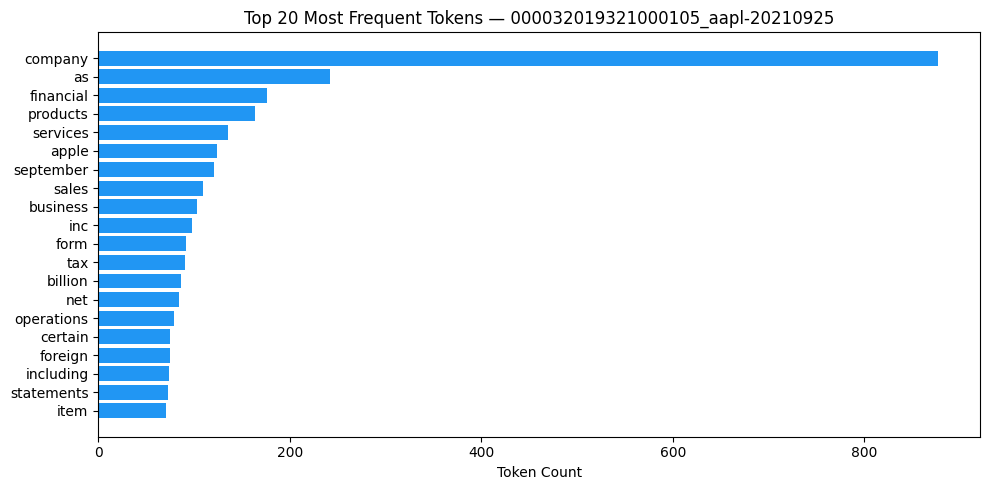

In [40]:
arr = first_vec.toarray().flatten()
top_indices = arr.argsort()[::-1][:20]
top_tokens = [vocab[i] for i in top_indices]
top_counts = [int(arr[i]) for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_tokens)), top_counts[::-1], color="#2196F3")
ax.set_yticks(range(len(top_tokens)))
ax.set_yticklabels(top_tokens[::-1], fontsize=10)
ax.set_xlabel("Token Count")
ax.set_title(f"Top 20 Most Frequent Tokens — {first_basename}")
plt.tight_layout()
plt.show()

---
## Section 4 — Year-over-Year Similarity

Consecutive 10-K filings are **paired** (current vs. prior year) with a gap filter of 200–550 days.

For each pair we compute:
- **Cosine similarity** on bag-of-words vectors (captures overall textual overlap)
- **Jaccard similarity** on lemmatized token sets (captures vocabulary overlap)

Higher similarity means the filing barely changed; lower similarity means material new/removed language.

In [41]:
filings = load_cleaned_filings(entity_dir)
pairs = pair_filings(filings)

print(f"Loaded {len(filings)} cleaned filings")
print(f"Formed {len(pairs)} year-over-year pair(s):\n")

for i, (cur, pri) in enumerate(pairs):
    print(f"  Pair {i+1}: {cur.get('_report_date', '?')}  vs  {pri.get('_report_date', '?')}")
    print(f"           current = {cur['_basename']}")
    print(f"           prior   = {pri['_basename']}\n")

Loaded 5 cleaned filings
Formed 4 year-over-year pair(s):

  Pair 1: 2022-09-24  vs  2021-09-25
           current = 000032019322000108_aapl-20220924
           prior   = 000032019321000105_aapl-20210925

  Pair 2: 2023-09-30  vs  2022-09-24
           current = 000032019323000106_aapl-20230930
           prior   = 000032019322000108_aapl-20220924

  Pair 3: 2024-09-28  vs  2023-09-30
           current = 000032019324000123_aapl-20240928
           prior   = 000032019323000106_aapl-20230930

  Pair 4: 2025-09-27  vs  2024-09-28
           current = 000032019325000079_aapl-20250927
           prior   = 000032019324000123_aapl-20240928



In [42]:
current, prior = pairs[0]

cur_vec = doc_vectors[current["_basename"]]
pri_vec = doc_vectors[prior["_basename"]]

doc_cosine = cosine_sim(cur_vec, pri_vec)
doc_jaccard = jaccard_sim(current["full_text"], prior["full_text"])

print(f"Document-level similarity  (Pair 1):")
print(f"  Cosine similarity  = {doc_cosine:.6f}")
print(f"  Jaccard similarity = {doc_jaccard:.6f}")
print(f"  Text change (1-cos)= {1 - doc_cosine:.6f}")

Document-level similarity  (Pair 1):
  Cosine similarity  = 0.997459
  Jaccard similarity = 0.895991
  Text change (1-cos)= 0.002541


In [43]:
cur_sections = current.get("sections", {})
pri_sections = prior.get("sections", {})
common = sorted(set(cur_sections.keys()) & set(pri_sections.keys()))

cur_sec_vecs = section_vectors.get(current["_basename"], {})
pri_sec_vecs = section_vectors.get(prior["_basename"], {})

section_sims = []
for sec in common:
    cv = cur_sec_vecs.get(sec)
    pv = pri_sec_vecs.get(sec)
    sec_cos = cosine_sim(cv, pv) if cv is not None and pv is not None else None
    sec_jac = jaccard_sim(cur_sections[sec], pri_sections[sec])
    section_sims.append({
        "section": sec,
        "cosine": round(sec_cos, 4) if sec_cos else None,
        "jaccard": round(sec_jac, 4),
        "text_change": round(1 - sec_cos, 4) if sec_cos else None,
    })

sec_df = pd.DataFrame(section_sims).sort_values("text_change", ascending=False)
sec_df

,section,cosine,jaccard,text_change
20,item_9b,0.1892,0.0746,0.8108
2,item_11,0.8367,0.6471,0.1633
4,item_13,0.8660,0.7143,0.1340
5,item_14,0.8718,0.7273,0.1282
3,item_12,0.8819,0.7500,0.1181
13,item_5,0.9549,0.8456,0.0451
1,item_10,0.9642,0.9655,0.0358
15,item_7,0.9681,0.7598,0.0319
0,item_1,0.9767,0.8050,0.0233
11,item_3,0.9802,0.8700,0.0198


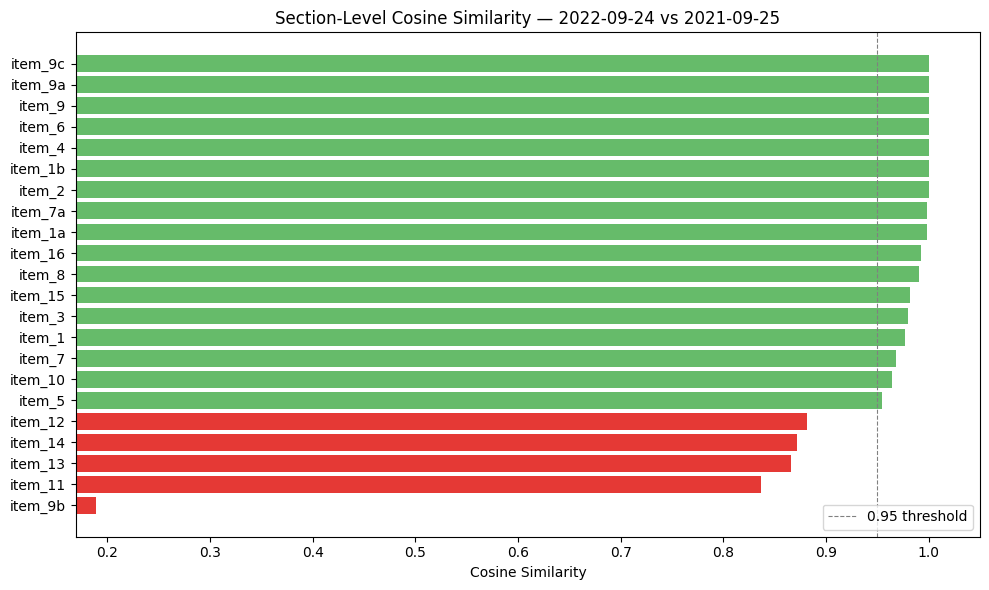

In [44]:
plot_df = sec_df.dropna(subset=["cosine"]).sort_values("cosine")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E53935" if c < 0.9 else "#FFA726" if c < 0.95 else "#66BB6A" for c in plot_df["cosine"]]
ax.barh(plot_df["section"], plot_df["cosine"], color=colors)
ax.set_xlabel("Cosine Similarity")
ax.set_title(f"Section-Level Cosine Similarity — {current.get('_report_date')} vs {prior.get('_report_date')}")
ax.axvline(x=0.95, color="gray", linestyle="--", linewidth=0.8, label="0.95 threshold")
ax.legend(loc="lower right")
ax.set_xlim(left=min(plot_df["cosine"].min() - 0.02, 0.7))
plt.tight_layout()
plt.show()

---
## Section 5 — Numerical Divergence

Bag-of-words similarity ignores numbers entirely (the tokenizer strips digits). The `numeric_change` module fills this gap:

1. **Extract** dollar amounts (`$5.3 billion`), percentages (`12.5%`), and large comma-separated numbers
2. **Match** numbers between current and prior year using context-word Jaccard similarity
3. **Score** divergence via mean log-ratio, squashed to [0, 1]

The final **change intensity** blends text and numeric signals:

`change_intensity = alpha * (1 - text_sim) + (1 - alpha) * numerical_divergence`

where `alpha = 0.7` (text-heavy, with numeric as a complement).

In [45]:
mda_current = cur_sections.get("item_7", "")[:5000]
mda_prior   = pri_sections.get("item_7", "")[:5000]

nums_cur = extract_financial_numbers(mda_current)
nums_pri = extract_financial_numbers(mda_prior)

print(f"Financial numbers extracted from Item 7 (MD&A):")
print(f"  Current year: {len(nums_cur)} numbers")
print(f"  Prior year  : {len(nums_pri)} numbers")

print(f"\nSample extracted numbers (current):")
for n in nums_cur[:8]:
    print(f"  {n['raw']:>25s}  ->  value = {n['value']:>15,.2f}")

Financial numbers extracted from Item 7 (MD&A):
  Current year: 8 numbers
  Prior year  : 8 numbers

Sample extracted numbers (current):
                         8%  ->  value =            8.00
              $28.5 billion  ->  value = 28,500,000,000.00
               $315 billion  ->  value = 315,000,000,000.00
               $405 billion  ->  value = 405,000,000,000.00
                     $0.22   ->  value =            0.22
                     $0.23   ->  value =            0.23
              $90.2 billion  ->  value = 90,200,000,000.00
              $14.8 billion  ->  value = 14,800,000,000.00


In [46]:
matched = match_numbers(nums_cur, nums_pri)
print(f"Matched {len(matched)} number pairs between current and prior year:\n")

for nc, np_ in matched[:10]:
    ratio = nc["value"] / np_["value"] if np_["value"] != 0 else float("inf")
    print(f"  {nc['raw']:>25s}  vs  {np_['raw']:<25s}  ratio = {ratio:.3f}")

Matched 8 number pairs between current and prior year:

                     $0.22   vs  $0.205                     ratio = 1.073
                     $0.23   vs  $0.22                      ratio = 1.045
              $90.2 billion  vs  $85.5 billion              ratio = 1.055
               $405 billion  vs  $225 billion               ratio = 1.800
               $315 billion  vs  $315 billion               ratio = 1.000
                         8%  vs  33%                        ratio = 0.242
              $28.5 billion  vs  $91.3 billion              ratio = 0.312
              $14.8 billion  vs  $14.5 billion              ratio = 1.021


In [47]:
doc_num_div = compute_numerical_divergence(current["full_text"], prior["full_text"])

alpha = config.NUMERIC_CHANGE_ALPHA
text_change = 1 - doc_cosine
hybrid_ci = alpha * text_change + (1 - alpha) * doc_num_div

print(f"Document-level metrics:")
print(f"  Text change (1 - cosine)    = {text_change:.6f}")
print(f"  Numerical divergence        = {doc_num_div:.6f}")
print(f"  Alpha (text weight)         = {alpha}")
print(f"  Hybrid change_intensity     = {hybrid_ci:.6f}")
print(f"  = {alpha} * {text_change:.4f} + {1-alpha} * {doc_num_div:.4f}")

Document-level metrics:
  Text change (1 - cosine)    = 0.002541
  Numerical divergence        = 0.158860
  Alpha (text weight)         = 0.7
  Hybrid change_intensity     = 0.049436
  = 0.7 * 0.0025 + 0.30000000000000004 * 0.1589


---
## Section 6 — Full Similarity Pipeline

`similarity.compute_similarity(entity_dir)` runs the complete pipeline:
- Loads cleaned filings and builds vectors
- Pairs consecutive filings
- Computes document-level and section-level cosine, Jaccard, numerical divergence, and hybrid change intensity

Each section is weighted by importance (MD&A = 0.30, Risk Factors = 0.25, Business = 0.15) to produce a **weighted change intensity**.

In [48]:
sim_results = compute_similarity(entity_dir)
print(f"Computed similarity for {len(sim_results)} filing pair(s)\n")

doc_level = []
for r in sim_results:
    doc_level.append({
        "current": r["current_report_date"],
        "prior": r["prior_report_date"],
        "cosine": r["similarity_cosine"],
        "jaccard": r["similarity_jaccard"],
        "num_divergence": r["numerical_divergence"],
        "change_intensity": r["change_intensity"],
    })

doc_df = pd.DataFrame(doc_level)
doc_df

Computed similarity for 4 filing pair(s)



,current,prior,cosine,jaccard,num_divergence,change_intensity
0,2022-09-24,2021-09-25,0.997459,0.895991,0.158860,0.049436
1,2023-09-30,2022-09-24,0.995750,0.894141,0.276836,0.086026
2,2024-09-28,2023-09-30,0.995991,0.909269,0.345950,0.106592
3,2025-09-27,2024-09-28,0.995228,0.901696,0.190972,0.060632


In [49]:
print("Section-level changes (top 5 per pair, sorted by change_intensity):\n")
for r in sim_results:
    print(f"--- {r['current_report_date']} vs {r['prior_report_date']} ---")
    for sc in r["section_changes"][:5]:
        ci = sc["change_intensity"]
        ci_str = f"{ci:.4f}" if ci is not None else "N/A"
        print(f"  {sc['section']:>12s}  change_intensity={ci_str}  "
              f"cosine={sc.get('similarity_cosine', 'N/A')}  "
              f"num_div={sc.get('numerical_divergence', 'N/A')}")
    print()

Section-level changes (top 5 per pair, sorted by change_intensity):

--- 2022-09-24 vs 2021-09-25 ---
       item_9b  change_intensity=0.5676  cosine=0.189175  num_div=0.0
       item_11  change_intensity=0.1143  cosine=0.83666  num_div=0.0
       item_13  change_intensity=0.0938  cosine=0.866025  num_div=0.0
       item_14  change_intensity=0.0898  cosine=0.87178  num_div=0.0
       item_12  change_intensity=0.0827  cosine=0.881917  num_div=0.0

--- 2023-09-30 vs 2022-09-24 ---
       item_9b  change_intensity=0.4034  cosine=0.4237  num_div=0.0
       item_7a  change_intensity=0.3755  cosine=0.877462  num_div=0.965899
        item_5  change_intensity=0.1873  cosine=0.85188  num_div=0.278819
        item_3  change_intensity=0.1822  cosine=0.739743  num_div=0.0
       item_16  change_intensity=0.1590  cosine=0.772871  num_div=0.0

--- 2024-09-28 vs 2023-09-30 ---
       item_1c  change_intensity=0.5601  cosine=0.199875  num_div=0.0
        item_3  change_intensity=0.2814  cosine=0.70299

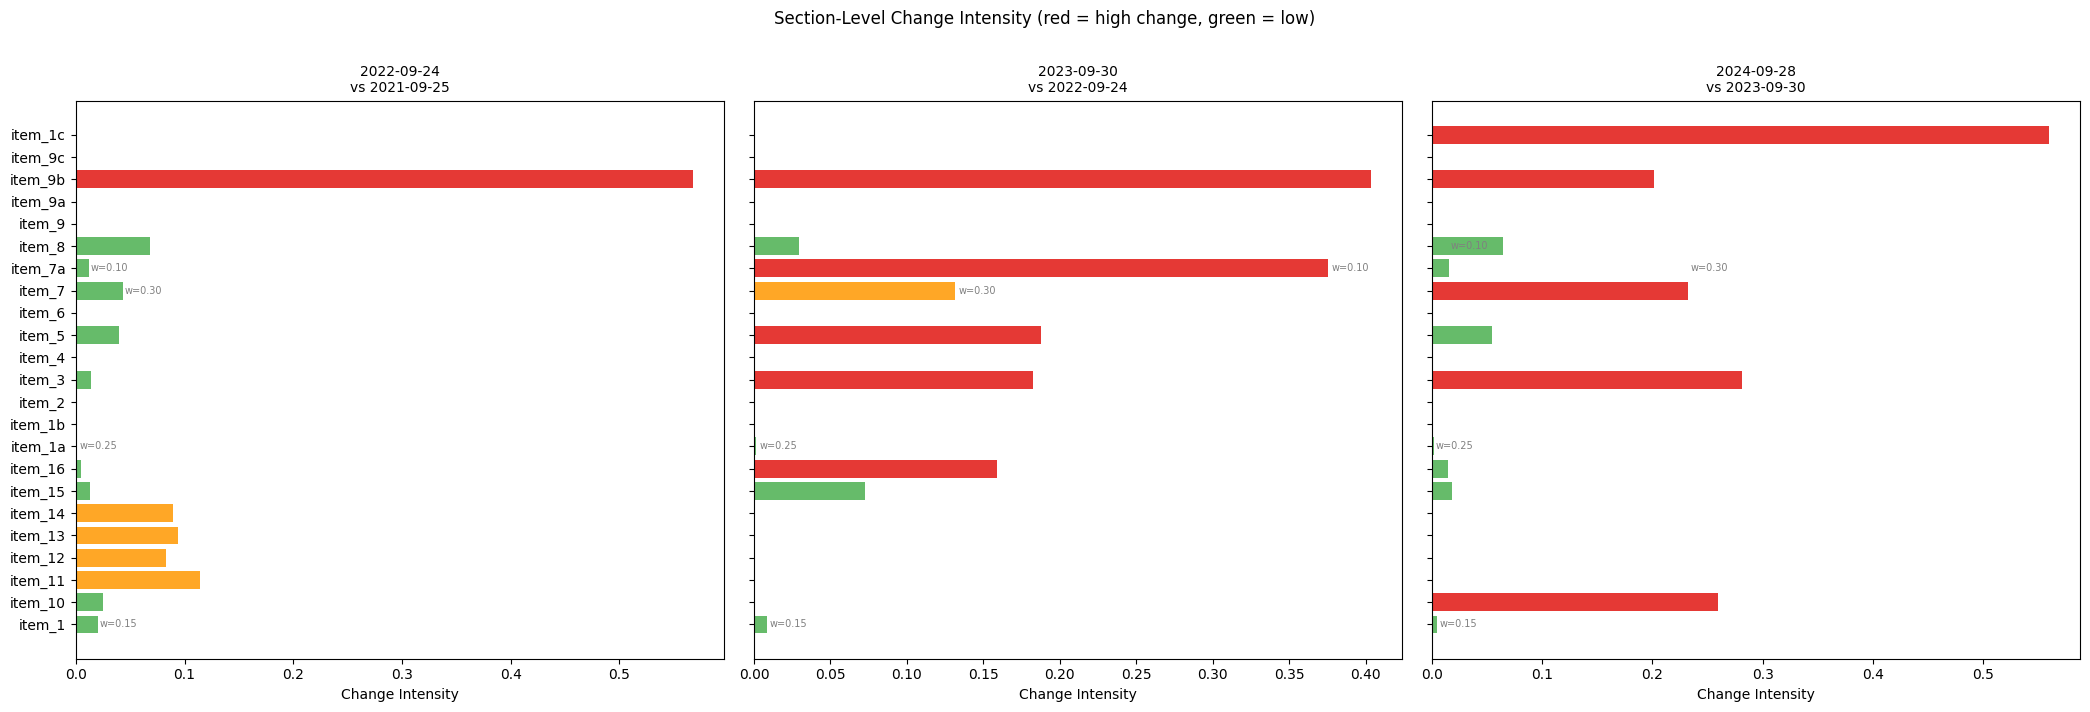

In [50]:
all_sections = config.ITEM_SECTIONS
n_pairs = len(sim_results)

if n_pairs > 0:
    fig, axes = plt.subplots(1, min(n_pairs, 3), figsize=(7 * min(n_pairs, 3), 7), sharey=True)
    if n_pairs == 1:
        axes = [axes]

    for idx, (ax, r) in enumerate(zip(axes, sim_results[:3])):
        sc_dict = {sc["section"]: sc.get("change_intensity", 0) or 0 for sc in r["section_changes"]}
        sections = sorted(sc_dict.keys())
        values = [sc_dict[s] for s in sections]
        weights = [config.SECTION_WEIGHTS.get(s, 0) for s in sections]

        colors = []
        for v in values:
            if v > 0.15:
                colors.append("#E53935")
            elif v > 0.08:
                colors.append("#FFA726")
            else:
                colors.append("#66BB6A")

        ax.barh(sections, values, color=colors)
        ax.set_xlabel("Change Intensity")
        ax.set_title(f"{r['current_report_date']}\nvs {r['prior_report_date']}", fontsize=10)

        for i, (v, w) in enumerate(zip(values, weights)):
            if w >= 0.10:
                ax.text(v + 0.002, i, f"w={w:.2f}", va="center", fontsize=7, color="gray")

    plt.suptitle("Section-Level Change Intensity (red = high change, green = low)", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

In [51]:
print("Section weights from config (inspired by LazyPrices paper):\n")
for sec, w in sorted(config.SECTION_WEIGHTS.items(), key=lambda x: -x[1]):
    bar = "█" * int(w * 100)
    print(f"  {sec:>12s}  {w:.2f}  {bar}")

for r in sim_results[:1]:
    w_ci = weighted_change_intensity(r["section_changes"])
    print(f"\nWeighted change intensity (Pair 1): {w_ci:.6f}")
    print(f"Raw document-level change intensity: {r['change_intensity']:.6f}")

Section weights from config (inspired by LazyPrices paper):

        item_7  0.30  ██████████████████████████████
       item_1a  0.25  █████████████████████████
        item_1  0.15  ███████████████
       item_7a  0.10  ██████████
        item_8  0.05  █████
       item_1b  0.02  ██
       item_1c  0.02  ██
        item_2  0.02  ██
        item_5  0.02  ██
       item_9a  0.02  ██
        item_3  0.01  █
        item_4  0.01  █
        item_6  0.01  █
        item_9  0.01  █
       item_9b  0.01  █
       item_10  0.01  █
       item_11  0.01  █
       item_12  0.01  █
       item_13  0.01  █
       item_14  0.01  █
       item_15  0.01  █

Weighted change intensity (Pair 1): 0.030509
Raw document-level change intensity: 0.049436


---
## Section 7 — Attention Proxy (Abnormal Volume)

The **attention proxy** measures whether investors paid attention to the filing by comparing trading volume around the filing date to a trailing baseline:

`attention_proxy = mean(event_window_volume) / mean(baseline_volume)`

- **Event window**: trading days (-1, +5) relative to filed date
- **Baseline**: 60 trading days before the event window (with a 5-day gap to avoid leakage)
- A ratio **> 1** = above-normal attention; **< 1** = investors were distracted

In [52]:
from run_pipeline import _enrich_filed_dates, _filing_metadata_from_dir

filings_meta = _filing_metadata_from_dir(entity_dir, CIK)
filings_meta = _enrich_filed_dates(CIK, filings_meta)

filed_dates = {}
for fm in filings_meta:
    if fm.get("filed_date"):
        filed_dates[fm["accession"]] = fm["filed_date"]

print(f"Filed dates for AAPL 10-K filings:\n")
for acc, fd in filed_dates.items():
    print(f"  {acc}  ->  filed {fd}")

Filed dates for AAPL 10-K filings:

  000032019321000105  ->  filed 2021-10-29
  000032019322000108  ->  filed 2022-10-28
  000032019323000106  ->  filed 2023-11-03
  000032019324000123  ->  filed 2024-11-01
  000032019325000079  ->  filed 2025-10-31


In [53]:
import yfinance as yf
from datetime import datetime, timedelta

attention_results = {}
sample_filed_date = None

for acc, fd in filed_dates.items():
    with contextlib.redirect_stderr(io.StringIO()):
        attn = get_attention_proxy(TICKER, fd)
    attention_results[fd] = attn
    if sample_filed_date is None and attn is not None:
        sample_filed_date = fd
    status = f"{attn:.4f}" if attn else "N/A"
    print(f"  Filed {fd}:  attention_proxy = {status}")

print(f"\nInterpretation: ratio > 1 = above-normal attention, < 1 = distracted investors")

  Filed 2021-10-29:  attention_proxy = 1.0327
  Filed 2022-10-28:  attention_proxy = 1.3551
  Filed 2023-11-03:  attention_proxy = 1.1054
  Filed 2024-11-01:  attention_proxy = 0.9391
  Filed 2025-10-31:  attention_proxy = 1.0223

Interpretation: ratio > 1 = above-normal attention, < 1 = distracted investors


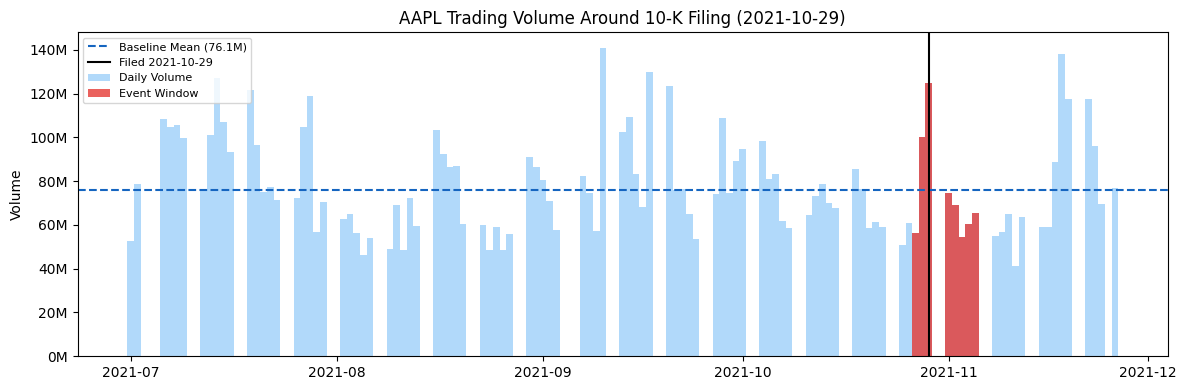

In [54]:
if sample_filed_date:
    fd_dt = datetime.strptime(sample_filed_date, "%Y-%m-%d")
    vol_start = (fd_dt - timedelta(days=120)).strftime("%Y-%m-%d")
    vol_end = (fd_dt + timedelta(days=30)).strftime("%Y-%m-%d")

    with contextlib.redirect_stderr(io.StringIO()):
        vol_data = yf.download(TICKER, start=vol_start, end=vol_end, progress=False, auto_adjust=True)

    if not vol_data.empty:
        volume = vol_data["Volume"].squeeze()
        if isinstance(volume, pd.DataFrame):
            volume = volume.iloc[:, 0]
        volume.index = volume.index.tz_localize(None) if volume.index.tz else volume.index
        filed_ts = pd.Timestamp(sample_filed_date)

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(volume.index, volume.values, width=1.0, color="#90CAF9", alpha=0.7, label="Daily Volume")

        event_mask = (volume.index >= filed_ts + pd.Timedelta(days=-2)) & \
                     (volume.index <= filed_ts + pd.Timedelta(days=8))
        ax.bar(volume.index[event_mask], volume.values[event_mask], width=1.0,
               color="#E53935", alpha=0.8, label="Event Window")

        baseline_end_dt = filed_ts - pd.Timedelta(days=8)
        baseline_start_dt = baseline_end_dt - pd.Timedelta(days=90)
        baseline_mask = (volume.index >= baseline_start_dt) & (volume.index <= baseline_end_dt)
        if baseline_mask.any():
            baseline_mean = volume[baseline_mask].mean()
            ax.axhline(y=baseline_mean, color="#1565C0", linestyle="--", linewidth=1.5,
                       label=f"Baseline Mean ({baseline_mean/1e6:.1f}M)")

        ax.axvline(x=filed_ts, color="black", linestyle="-", linewidth=1.5, label=f"Filed {sample_filed_date}")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M"))
        ax.set_ylabel("Volume")
        ax.set_title(f"AAPL Trading Volume Around 10-K Filing ({sample_filed_date})")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

---
## Section 8 — Cumulative Abnormal Return (CAR)

CAR measures the stock's market-adjusted performance around the filing date:

`CAR = sum( stock_return[t] - market_return[t] )  for t in event_window`

- **Market proxy**: S&P 500 (`^GSPC`)
- **Event window**: trading days (-1, +5) relative to filed date
- A positive CAR means the stock outperformed the market after the filing
- A large |CAR| combined with low attention suggests underreaction (core LazyPrices insight)

In [55]:
car_results = {}
for acc, fd in filed_dates.items():
    with contextlib.redirect_stderr(io.StringIO()):
        result = compute_car(TICKER, fd)
    car_results[fd] = result
    car_val = result.get("car")
    status = f"{car_val:+.6f}" if car_val is not None else "N/A"
    print(f"  Filed {fd}:  CAR = {status}  (window {result['window']})")

print(f"\nMarket proxy: {config.MARKET_TICKER}")
print(f"Event window: {config.CAR_WINDOW} trading days relative to filing")

  Filed 2021-10-29:  CAR = -0.013408  (window [-1, 5])
  Filed 2022-10-28:  CAR = -0.054542  (window [-1, 5])
  Filed 2023-11-03:  CAR = +0.029666  (window [-1, 5])
  Filed 2024-11-01:  CAR = -0.043539  (window [-1, 5])
  Filed 2025-10-31:  CAR = +0.019053  (window [-1, 5])

Market proxy: ^GSPC
Event window: (-1, 5) trading days relative to filing


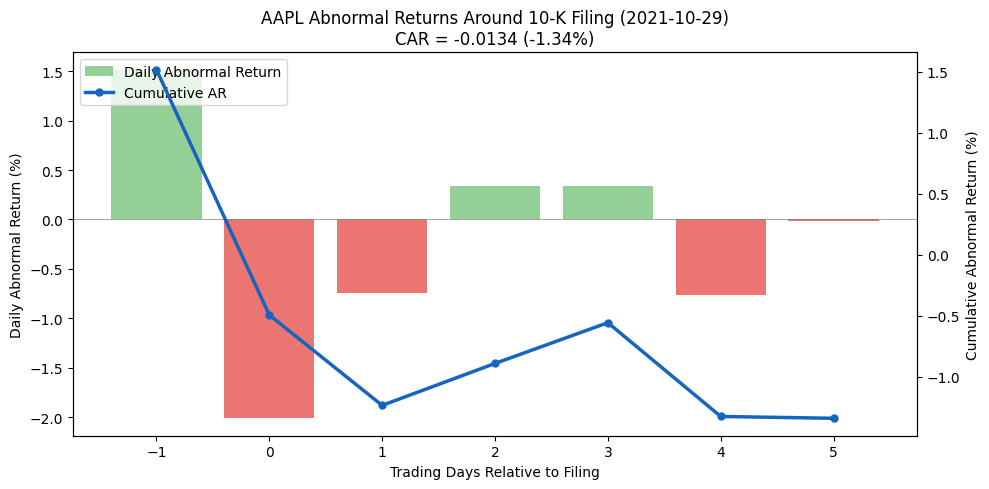

In [56]:
sample_car = None
sample_car_date = None
for fd, result in car_results.items():
    if result.get("daily_abnormal"):
        sample_car = result
        sample_car_date = fd
        break

if sample_car and sample_car["daily_abnormal"]:
    daily = sample_car["daily_abnormal"]
    cumulative = np.cumsum(daily)
    days = list(range(config.CAR_WINDOW[0], config.CAR_WINDOW[0] + len(daily)))

    fig, ax1 = plt.subplots(figsize=(10, 5))

    colors = ["#66BB6A" if d >= 0 else "#E53935" for d in daily]
    ax1.bar(days, [d * 100 for d in daily], color=colors, alpha=0.7, label="Daily Abnormal Return")
    ax1.set_xlabel("Trading Days Relative to Filing")
    ax1.set_ylabel("Daily Abnormal Return (%)")
    ax1.axhline(y=0, color="gray", linewidth=0.5)

    ax2 = ax1.twinx()
    ax2.plot(days, [c * 100 for c in cumulative], color="#1565C0", linewidth=2.5,
             marker="o", markersize=5, label="Cumulative AR")
    ax2.set_ylabel("Cumulative Abnormal Return (%)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax1.set_title(f"AAPL Abnormal Returns Around 10-K Filing ({sample_car_date})\n"
                  f"CAR = {sample_car['car']:+.4f} ({sample_car['car']*100:+.2f}%)")
    ax1.set_xticks(days)
    plt.tight_layout()
    plt.show()
else:
    print("No daily abnormal return data available for visualization.")

---
## Section 9 — Lazy Attention Score (LAS) Computation

The **LAS** combines three signals into a single score for each filing:

```
LAS = w_change    * f(change_intensity)
    - w_attention * f(attention_proxy)
    + w_car       * f(|CAR|)
```

Where:
- `f()` = cross-sectional **rank-percentile normalization** (maps to [0, 1])
- `w_change = 0.50` — more textual change pushes LAS up
- `w_attention = 0.25` — *subtracted* — high attention reduces LAS (investors already noticed)
- `w_car = 0.25` — large absolute return pushes LAS up

**High LAS** = material disclosure changes + low investor attention + significant price movement = potential underreaction.

In [57]:
rows = []
for r in sim_results:
    w_ci = weighted_change_intensity(r["section_changes"])
    ci = w_ci if w_ci is not None else r["change_intensity"]

    fd = None
    for fm in filings_meta:
        acc_no_dash = fm["accession"].replace("-", "")
        if acc_no_dash in r["current_basename"]:
            fd = fm.get("filed_date")
            break

    attn = attention_results.get(fd) if fd else None
    car_val = car_results.get(fd, {}).get("car") if fd else None

    rows.append({
        "report_date": r["current_report_date"],
        "filed_date": fd,
        "change_intensity": ci,
        "attention_proxy": attn,
        "car": car_val,
    })

las_input_df = pd.DataFrame(rows)
print("LAS input features:\n")
las_input_df

LAS input features:



,report_date,filed_date,change_intensity,attention_proxy,car
0,2022-09-24,2022-10-28,0.030509,1.355055,-0.054542
1,2023-09-30,2023-11-03,0.086948,1.105361,0.029666
2,2024-09-28,2024-11-01,0.089989,0.939063,-0.043539
3,2025-09-27,2025-10-31,0.032886,1.022288,0.019053


In [58]:
las_df = compute_las(las_input_df)
print(f"LAS weights: {config.LAS_WEIGHTS}")
print(f"Normalization method: {config.LAS_NORMALIZATION}\n")

display_cols = ["report_date", "change_intensity", "attention_proxy", "car",
                "norm_change", "norm_attention", "norm_car", "las"]
existing_cols = [c for c in display_cols if c in las_df.columns]
las_df[existing_cols]

LAS weights: {'w_change': 0.5, 'w_attention': 0.25, 'w_car': 0.25}
Normalization method: rank



,report_date,change_intensity,attention_proxy,car,norm_change,norm_attention,norm_car,las
0,2022-09-24,0.030509,1.355055,-0.054542,0.25,1.00,1.00,0.1250
1,2023-09-30,0.086948,1.105361,0.029666,0.75,0.75,0.50,0.3125
2,2024-09-28,0.089989,0.939063,-0.043539,1.00,0.25,0.75,0.6250
3,2025-09-27,0.032886,1.022288,0.019053,0.50,0.50,0.25,0.1875


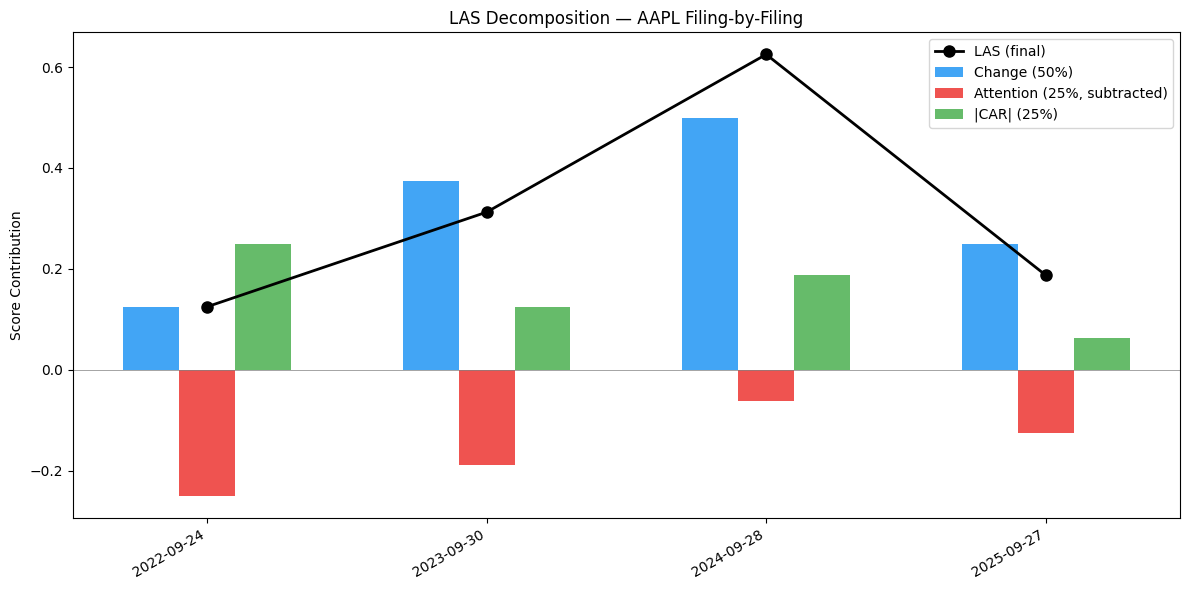

In [59]:
plot_data = las_df.dropna(subset=["las"]).copy()

if not plot_data.empty:
    w = config.LAS_WEIGHTS
    labels = plot_data["report_date"].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 6))

    change_contrib = (w["w_change"] * plot_data["norm_change"]).values
    attn_contrib   = (-w["w_attention"] * plot_data["norm_attention"]).values
    car_contrib    = (w["w_car"] * plot_data["norm_car"]).values

    ax.bar(x - width, change_contrib, width, label=f'Change ({w["w_change"]:.0%})', color="#42A5F5")
    ax.bar(x,         attn_contrib,   width, label=f'Attention ({w["w_attention"]:.0%}, subtracted)', color="#EF5350")
    ax.bar(x + width, car_contrib,    width, label=f'|CAR| ({w["w_car"]:.0%})', color="#66BB6A")

    ax.plot(x, plot_data["las"].values, "ko-", markersize=8, linewidth=2, label="LAS (final)")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Score Contribution")
    ax.set_title("LAS Decomposition — AAPL Filing-by-Filing")
    ax.legend()
    ax.axhline(y=0, color="gray", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No valid LAS data to plot.")

In [60]:
if sim_results:
    sec_las = compute_section_las(sim_results[0]["section_changes"])
    sec_las_df = pd.DataFrame(sec_las)[["section", "change_intensity", "section_las"]].sort_values(
        "section_las", ascending=False
    )
    print(f"Section-level LAS (rank-normalized change intensity) — most recent pair:\n")
    print(sec_las_df.to_string(index=False))

Section-level LAS (rank-normalized change intensity) — most recent pair:

section  change_intensity  section_las
item_9b          0.567577     1.000000
item_11          0.114338     0.954545
item_13          0.093782     0.909091
item_14          0.089754     0.863636
item_12          0.082658     0.818182
 item_8          0.068513     0.772727
 item_7          0.043168     0.727273
 item_5          0.040107     0.681818
item_10          0.025054     0.636364
 item_1          0.020048     0.590909
 item_3          0.013827     0.545455
item_15          0.012845     0.500000
item_7a          0.011969     0.454545
item_16          0.005161     0.409091
item_1a          0.001393     0.363636
item_1b          0.000000     0.181818
 item_2         -0.000000     0.181818
 item_4          0.000000     0.181818
 item_6          0.000000     0.181818
 item_9          0.000000     0.181818
item_9a          0.000000     0.181818
item_9c          0.000000     0.181818


---
## Section 10 — Store Results in SQLite

All computed features are persisted to a **SQLite database** (or PostgreSQL in production) via `LASStore`.

Each row stores: CIK, ticker, accession, dates, similarity scores, change intensity, attention proxy, CAR, normalized components, LAS, and section-level change details as JSON.

In [61]:
db = LASStore()

for idx, row in las_df.iterrows():
    r = row.to_dict()
    sr = sim_results[idx] if idx < len(sim_results) else {}
    sec_changes = sr.get("section_changes", [])

    db.upsert({
        "cik": CIK,
        "entity_name": facts.get("entityName"),
        "accession": filings_meta[idx]["accession"] if idx < len(filings_meta) else f"demo_{idx}",
        "filed_date": r.get("filed_date"),
        "report_date": r.get("report_date"),
        "ticker": TICKER,
        "similarity_cosine": sr.get("similarity_cosine"),
        "similarity_jaccard": sr.get("similarity_jaccard"),
        "numerical_divergence": sr.get("numerical_divergence"),
        "change_intensity": r.get("change_intensity"),
        "attention_proxy": r.get("attention_proxy"),
        "car": r.get("car"),
        "las": r.get("las"),
        "norm_change": r.get("norm_change"),
        "norm_attention": r.get("norm_attention"),
        "norm_car": r.get("norm_car"),
        "section_changes_json": json.dumps(compute_section_las(sec_changes)),
    })

print(f"Upserted {len(las_df)} filing(s) to database\n")

stored = db.get_filings_by_tickers(["AAPL"])
cols = ["ticker", "report_date", "filed_date", "change_intensity", "attention_proxy", "car", "las"]
existing = [c for c in cols if c in stored.columns]
stored[existing]

Upserted 4 filing(s) to database



,ticker,report_date,filed_date,change_intensity,attention_proxy,car,las
0,AAPL,2022-09-24,2022-10-28,0.030509,1.355055,-0.054542,0.1250
1,AAPL,2023-09-30,2023-11-03,0.086948,1.105361,0.029666,0.3125
2,AAPL,2024-09-28,2024-11-01,0.089989,0.939063,-0.043539,0.6250
3,AAPL,2025-09-27,2025-10-31,0.004772,1.022288,0.019053,0.5000
4,AAPL,2025-09-27,2025-10-31,0.032886,1.022288,0.019053,0.1875


---
## Section 11 — Advisor Query Layer

The `advisor_query` module sits on top of the database and provides portfolio-level intelligence:

1. **`aggregate_las`** — computes a weighted portfolio LAS across all holdings
2. **`retrieve_high_impact_sections`** — finds the most-changed disclosure sections with text snippets
3. **`generate_explanation`** — produces a narrative summary (uses LLM if OpenAI key is set, otherwise a template fallback)

This is what an **investment advisor** would see in the dashboard.

In [62]:
portfolio = aggregate_las(["AAPL"], db=db)

print(f"Portfolio LAS: {portfolio['portfolio_las']}")
print(f"LAS Weights:   {portfolio.get('las_weights', config.LAS_WEIGHTS)}\n")

print("Holdings:")
for h in portfolio["holdings"]:
    las_str = f"{h['las']:.4f}" if h.get("las") is not None else "N/A"
    print(f"  {h['ticker']:>6s}  LAS={las_str}  "
          f"change={h.get('change_intensity', 'N/A')}  "
          f"attn={h.get('attention_proxy', 'N/A')}  "
          f"car={h.get('car', 'N/A')}")

Portfolio LAS: 0.5
LAS Weights:   {'w_change': 0.5, 'w_attention': 0.25, 'w_car': 0.25}

Holdings:
    AAPL  LAS=0.5000  change=0.004772  attn=1.022288  car=0.019053


In [63]:
high_impact = retrieve_high_impact_sections(["AAPL"], top_n=5, db=db)

print(f"Top {len(high_impact)} highest-impact disclosure sections:\n")
for s in high_impact:
    ci = s.get("change_intensity")
    ci_str = f"{ci:.4f}" if ci is not None else "N/A"
    print(f"  [{s['ticker']}] {s['section']:>12s}  change_intensity={ci_str}")
    snippet = s.get("snippet", "")[:200]
    if snippet:
        print(f"           \"{snippet}...\"")
    print()

Top 5 highest-impact disclosure sections:

  [AAPL]      item_9b  change_intensity=0.8375
           "Item 9B. Other Information
On October 31, 2025, the Company announced that Chris Kondo, Senior Director of Corporate Accounting and Principal Accounting Officer, will transition from his role on Janua..."

  [AAPL]      item_10  change_intensity=0.3704
           "PART III
Item 10. Directors, Executive Officers and Corporate Governance
The information required by this Item will be included in the Company’s definitive proxy statement to be filed with the SEC wit..."

  [AAPL]      item_16  change_intensity=0.2928
           "Item 16. Form 10-K Summary
None.
Apple Inc. | 2025 Form 10-K | 57
SIGNATURES
Pursuant to the requirements of Section 13 or 15(d) of the Securities Exchange Act of 1934, the Registrant has duly caused ..."

  [AAPL]       item_3  change_intensity=0.0708
           "Item 3. Legal Proceedings
Digital Markets Act Investigations
On March 25, 2024, the Commission announce

In [64]:
narrative = generate_explanation(portfolio, high_impact)
print("=" * 70)
print("ADVISOR NARRATIVE")
print("=" * 70)
print(narrative)

ADVISOR NARRATIVE
**Portfolio Lazy Attention Score (LAS) Analysis Narrative**

The portfolio's overall Lazy Attention Score (LAS) stands at 0.5, indicating a moderate level of investor attention relative to the changes in SEC 10-K filings. The primary holding contributing to this score is Apple Inc. (AAPL), which has shown significant disclosure changes in its latest filing dated September 27, 2025.

### Key Findings on Apple Inc. (AAPL)

1. **High Impact Sections**:
   - **Item 9B: Other Information**: Notably, there was a substantial change in this section, with a change intensity of 0.837471. The disclosure regarding the transition of Chris Kondo from Senior Director of Corporate Accounting to a new role, alongside the appointment of Ben Borders as the new Principal Accounting Officer, is critical for stakeholders assessing corporate governance and management stability.
   
   - **Item 10: Directors, Executive Officers and Corporate Governance**: This section also exhibited a signif

---
## Section 12 — End-to-End Summary

### Complete Pipeline Flow

```
  ┌─────────────┐
  │  SEC EDGAR   │  Pull 10-K HTML filings
  └──────┬───────┘
         ▼
  ┌─────────────┐
  │ Extract &    │  Strip HTML, split into 21 standard sections
  │ Clean        │  Output: cleaned JSON per filing
  └──────┬───────┘
         ▼
  ┌─────────────┐
  │ Embeddings   │  Tokenize, lemmatize, CountVectorizer (50K features)
  │ (BoW)        │  Output: sparse doc + section vectors
  └──────┬───────┘
         ▼
  ┌─────────────┐     ┌──────────────────┐
  │  Similarity  │◄────│ Numeric Change   │  Extract $, %, numbers; match by context
  │  (YoY pairs) │     │ Divergence       │  Log-ratio divergence in [0,1]
  └──────┬───────┘     └──────────────────┘
         │  change_intensity = 0.7*(1-cosine) + 0.3*num_divergence
         ▼
  ┌─────────────┐     ┌──────────────────┐     ┌──────────────────┐
  │  Weighted    │     │ Attention Proxy   │     │ CAR              │
  │  Change      │     │ (Volume Ratio)    │     │ (Market-Adjusted)│
  │  Intensity   │     │ Event vs Baseline │     │ Window: (-1,+5)  │
  └──────┬───────┘     └────────┬──────────┘     └────────┬─────────┘
         │                      │                          │
         └──────────────────────┼──────────────────────────┘
                                ▼
                    ┌────────────────────┐
                    │  LAS Computation    │
                    │  0.50*f(change)     │
                    │ -0.25*f(attention)  │
                    │ +0.25*f(|CAR|)      │
                    └─────────┬──────────┘
                              ▼
                    ┌────────────────────┐
                    │  SQLite / Store     │
                    └─────────┬──────────┘
                              ▼
                    ┌────────────────────┐
                    │  Advisor Query      │
                    │  Portfolio LAS      │
                    │  High-Impact Sections│
                    │  Narrative          │
                    └────────────────────┘
```

In [65]:
print("=" * 70)
print("AAPL LazyPrices Pipeline — Summary Table")
print("=" * 70)

summary_cols = ["report_date", "filed_date", "change_intensity",
                "attention_proxy", "car", "norm_change",
                "norm_attention", "norm_car", "las"]
existing = [c for c in summary_cols if c in las_df.columns]
print(las_df[existing].to_string(index=False))

print(f"\n{'─' * 70}")
print("Key Takeaways:")
print("─" * 70)
print(f"  • Filings analyzed     : {len(las_df)}")

valid_las = las_df["las"].dropna()
if not valid_las.empty:
    print(f"  • Mean LAS             : {valid_las.mean():.4f}")
    print(f"  • Max LAS              : {valid_las.max():.4f} (most underreacted filing)")
    print(f"  • Min LAS              : {valid_las.min():.4f} (least underreacted filing)")

valid_ci = las_df["change_intensity"].dropna()
if not valid_ci.empty:
    print(f"  • Mean Change Intensity: {valid_ci.mean():.4f}")

print(f"\n  • LAS Weights: change={config.LAS_WEIGHTS['w_change']}, "
      f"attention={config.LAS_WEIGHTS['w_attention']}, "
      f"car={config.LAS_WEIGHTS['w_car']}")
print(f"  • Normalization: {config.LAS_NORMALIZATION}")
print(f"  • Hybrid alpha (text vs numeric): {config.NUMERIC_CHANGE_ALPHA}")

AAPL LazyPrices Pipeline — Summary Table
report_date filed_date  change_intensity  attention_proxy       car  norm_change  norm_attention  norm_car    las
 2022-09-24 2022-10-28          0.030509         1.355055 -0.054542         0.25            1.00      1.00 0.1250
 2023-09-30 2023-11-03          0.086948         1.105361  0.029666         0.75            0.75      0.50 0.3125
 2024-09-28 2024-11-01          0.089989         0.939063 -0.043539         1.00            0.25      0.75 0.6250
 2025-09-27 2025-10-31          0.032886         1.022288  0.019053         0.50            0.50      0.25 0.1875

──────────────────────────────────────────────────────────────────────
Key Takeaways:
──────────────────────────────────────────────────────────────────────
  • Filings analyzed     : 4
  • Mean LAS             : 0.3125
  • Max LAS              : 0.6250 (most underreacted filing)
  • Min LAS              : 0.1250 (least underreacted filing)
  • Mean Change Intensity: 0.0601

  • LAS We

In [66]:
db.close()
print("Database connection closed. Demo complete.")

Database connection closed. Demo complete.


---

### Interpretation Guide

| LAS Range | Meaning |
|-----------|---------|
| **High LAS (> 0.4)** | Material disclosure changes + low investor attention + significant price reaction = **potential underreaction** worth investigating |
| **Medium LAS (0.2 - 0.4)** | Moderate changes or mixed signals — standard monitoring |
| **Low LAS (< 0.2)** | Filing barely changed, or investors already priced in changes — low priority |

### Key Configuration Parameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `NUMERIC_CHANGE_ALPHA` | 0.7 | Text vs. numeric blend weight |
| `LAS_WEIGHTS` | change=0.50, attention=0.25, car=0.25 | Component weights in LAS formula |
| `LAS_NORMALIZATION` | rank | Cross-sectional normalization method |
| `CAR_WINDOW` | (-1, +5) | Trading days around filing |
| `SECTION_WEIGHTS` | MD&A=0.30, Risk=0.25, Business=0.15 | Section importance for weighted change intensity |